 19 iter, mse: 0.1176

Final weights (including bias): [0.0476174  0.92451224]


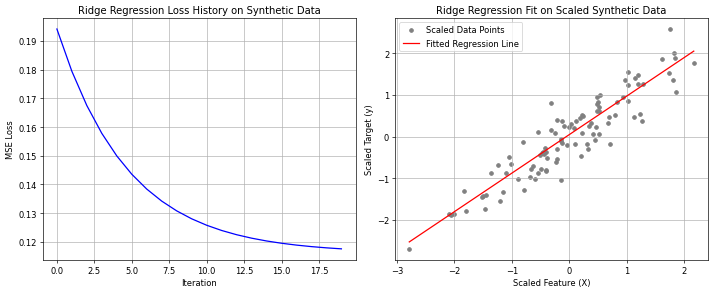

In [4]:
import math
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from sklearn.datasets import make_regression
from sklearn.preprocessing import StandardScaler # Added for standardization

class ridge_reg():

    def __init__(self, n_iter=20, learning_rate=1e-3, lmbda=0.1):
        self.n_iter = n_iter
        self.learning_rate = learning_rate
        self.lmbda = lmbda

    def fit(self, X, y):
        #insert const 1 for bias term
        X = np.insert(X, 0, 1, axis=1)

        self.loss = []
        self.w = np.random.rand(X.shape[1])

        for i in range(self.n_iter):
            y_pred = X.dot(self.w)
            # Corrected MSE calculation for Ridge Regression
            mse = np.mean(0.5*(y - y_pred)**2) + 0.5*self.lmbda*self.w[1:].T.dot(self.w[1:]) # L2 regularization only on non-bias terms
            self.loss.append(mse)
            #compute gradient of NLL(w) wrt w
            grad_w = - (y - y_pred).dot(X)
            # Add L2 regularization gradient for non-bias terms
            grad_w[1:] += self.lmbda*self.w[1:]
            #update the weights
            self.w -= self.learning_rate * grad_w
        print(" %d iter, mse: %.4f" %(i, mse))

    def predict(self, X):
        #insert const 1 for bias term
        X = np.insert(X, 0, 1, axis=1)
        y_pred = X.dot(self.w)
        return y_pred

if __name__ == "__main__":
    # Generate a new synthetic regression dataset
    X_new, y_new = make_regression(n_samples=100, n_features=1, noise=20, random_state=42)

    # Instantiate and fit-transform StandardScaler for features
    scaler_X = StandardScaler()
    X_new_scaled = scaler_X.fit_transform(X_new)

    # Instantiate and fit-transform StandardScaler for target
    scaler_y = StandardScaler()
    y_new_scaled = scaler_y.fit_transform(y_new.reshape(-1, 1)).flatten() # Flatten for model input

    rr = ridge_reg()
    rr.fit(X_new_scaled, y_new_scaled)

    # Print final weights
    print("\nFinal weights (including bias):", rr.w)

    # Consolidated figure with two subplots
    plt.figure(figsize=(12, 5), dpi=60)

    # Subplot 1: Loss History
    plt.subplot(1, 2, 1)
    plt.plot(rr.loss, color='blue')
    plt.title('Ridge Regression Loss History on Synthetic Data')
    plt.xlabel('Iteration')
    plt.ylabel('MSE Loss')
    plt.grid(True)

    # Subplot 2: Scatter plot with fitted regression line
    plt.subplot(1, 2, 2)
    plt.scatter(X_new_scaled, y_new_scaled, color='gray', label='Scaled Data Points', s=20)

    # Generate points for the regression line
    x_line = np.linspace(X_new_scaled.min(), X_new_scaled.max(), 100).reshape(-1, 1)
    y_line = rr.predict(x_line)

    plt.plot(x_line, y_line, color='red', label='Fitted Regression Line')
    plt.title('Ridge Regression Fit on Scaled Synthetic Data')
    plt.xlabel('Scaled Feature (X)')
    plt.ylabel('Scaled Target (y)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()